In [4]:
# campaign.csvデータを読み込み
import pandas as pd

campaign = pd.read_csv("../data/campaign.csv", dtype={"customer_id": str})

# campainデータの確認
campaign.head()

,customer_id,campaign_a,campaign_b,campaign_c,age,gender,campaignb_purchase_amount
0,00035660,False,False,False,46,1,24700
1,00052780,False,False,False,54,1,40300
2,00023790,False,False,False,22,1,10100
3,00017961,False,False,False,37,1,23100
4,00030623,False,False,False,29,1,11400


In [5]:
# campaign_bのクラス分布を確認。T/Fを確認します。
# 可視化も行いたいのでここでインポートしておきましょう。
# 視化のライブラリをインポート
import matplotlib.pyplot as plt
import seaborn as sns

# キャンペーンBのTrue/Falseの件数を集計
campaign_b_counts = campaign["campaign_b"].value_counts()
campaign_b_counts

campaign_b
False    16766
True       157
Name: count, dtype: int64

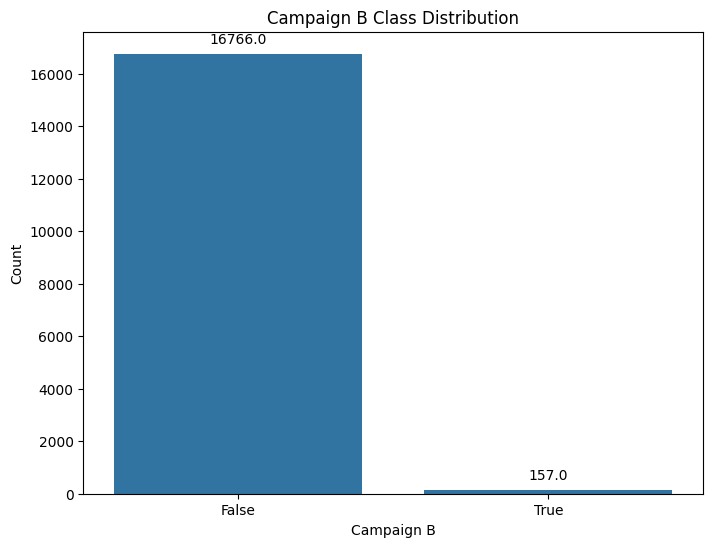

In [6]:
# 可視化も行うように心がけておきましょう
# グラフを描画
plt.figure(figsize=(8, 6))
sns.countplot(x="campaign_b", data=campaign)

# 棒グラフの上に件数を表示
for p in plt.gca().patches:
    plt.gca().annotate(
        f"{p.get_height()}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 10),
        textcoords="offset points",
    )
plt.title("Campaign B Class Distribution")
plt.xlabel("Campaign B")
plt.ylabel("Count")

plt.show()

In [8]:
# 重み付け処理の追加部分
# xgboostのインポート
from xgboost import XGBClassifier

# 機械学習のデータ分割のインポートを追加
from sklearn.model_selection import train_test_split

# クラスの件数をカウント
count_negative = (campaign["campaign_b"] == False).sum()
count_positive = (campaign["campaign_b"] == True).sum()

# 重みの計算
scale_pos_weight = count_negative / count_positive

# 特徴量とターゲットに分割（customer_idを除外）
X = campaign.drop(columns=["customer_id", "campaign_b"])
y = campaign["campaign_b"]

# 学習用・テスト用に分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# モデル学習
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric="logloss"
)
model.fit(X_train, y_train)

/Users/maton/.pyenv/versions/3.10.13/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:09:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

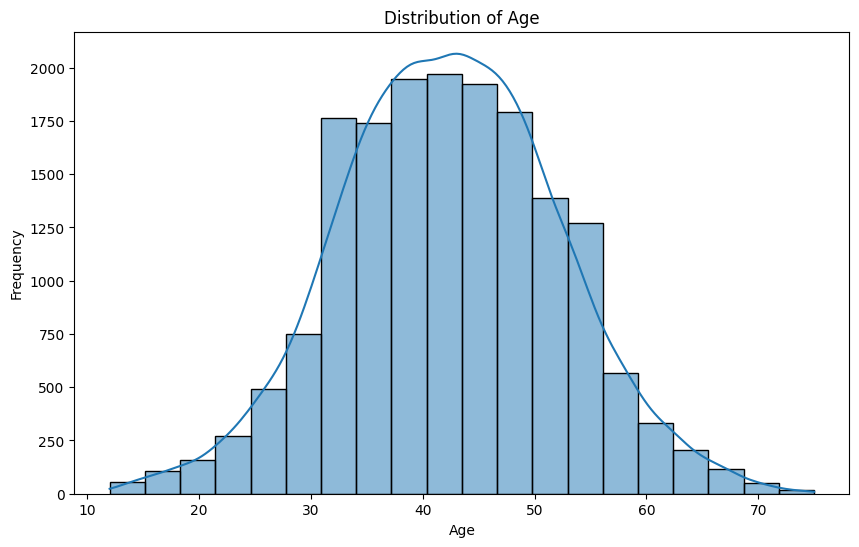

In [9]:
# campaignデータのage、gender、campaignb_purchese_amountの分布をそれぞれ確認します。
# まずはageの分布を確認
plt.figure(figsize=(10, 6))
sns.histplot(campaign["age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

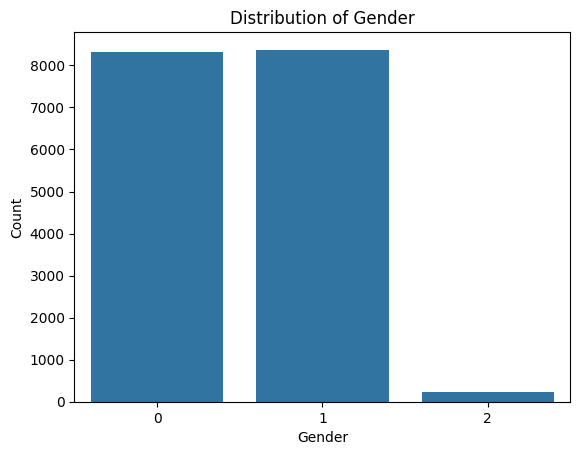

In [10]:
# genderの分布を確認
sns.countplot(x="gender", data=campaign)
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

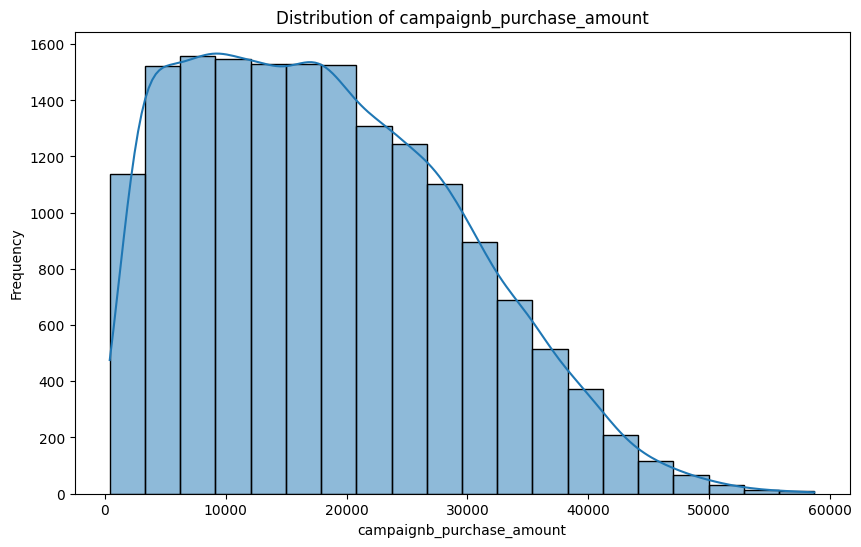

In [11]:
# campaign_b_purchase_amountの分布を確認
plt.figure(figsize=(10, 6))
sns.histplot(campaign["campaignb_purchase_amount"], bins=20, kde=True)
plt.title("Distribution of campaignb_purchase_amount")
plt.xlabel("campaignb_purchase_amount")
plt.ylabel("Frequency")
plt.show()